In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import warnings

warnings.filterwarnings("ignore")

# Define URLs for each client's dataset
client_1_url = "https://raw.githubusercontent.com/Me-Rajdip/Data-Set/refs/heads/main/VFL%20Dataset/Modified_Cardiovascular_Disease_Dataset.csv"
client_2_url = "https://raw.githubusercontent.com/Me-Rajdip/Data-Set/refs/heads/main/VFL%20Dataset/heart.csv"
client_3_url = "https://raw.githubusercontent.com/Me-Rajdip/Data-Set/refs/heads/main/VFL%20Dataset/Cardiovascular_Disease_Dataset.csv"
client_4_url = "https://raw.githubusercontent.com/Me-Rajdip/Data-Set/refs/heads/main/VFL%20Dataset/heart_disease_dataset.csv"

# Load the datasets
client_1_df = pd.read_csv(client_1_url)
client_2_df = pd.read_csv(client_2_url)
client_3_df = pd.read_csv(client_3_url)
client_4_df = pd.read_csv(client_4_url)

# Drop "Unnamed" column from client_1_df
client_1_df = client_1_df.loc[:, ~client_1_df.columns.str.contains('^Unnamed')]

# Drop "patientid" column from client_3_df
client_3_df = client_3_df.drop(columns=["patientid"], errors='ignore')
client_4_df = client_4_df.drop(columns=["Patient ID"], errors='ignore')

# Target variable for each client
client_1_target = 'target'
client_2_target = 'HeartDisease'
client_3_target = 'target'
client_4_target = 'heart_disease'

# Separate numeric and categorical columns for Client 2
client_2_numeric_cols = client_2_df.select_dtypes(include=[np.number]).columns.tolist()
client_2_categorical_cols = client_2_df.select_dtypes(exclude=[np.number]).columns.tolist()


# Fill missing values for numeric columns with median
client_1_df = client_1_df.fillna(client_1_df.median())
client_2_df[client_2_numeric_cols] = client_2_df[client_2_numeric_cols].fillna(client_2_df[client_2_numeric_cols].median())
client_3_df = client_3_df.fillna(client_3_df.median())
client_4_df = client_4_df.fillna(client_4_df.median())

# Apply one-hot encoding for categorical columns in Client 2
encoder = OneHotEncoder(drop='first', sparse_output=False)
client_2_encoded = pd.DataFrame(encoder.fit_transform(client_2_df[client_2_categorical_cols]))
client_2_encoded.columns = encoder.get_feature_names_out(client_2_categorical_cols)
# Drop original categorical columns and concatenate the encoded ones
client_2_df = pd.concat([client_2_df[client_2_numeric_cols], client_2_encoded], axis=1)


# Split the data into train and test sets
client_1_train, client_1_test = train_test_split(client_1_df, test_size=0.2, random_state=42)
client_2_train, client_2_test = train_test_split(client_2_df, test_size=0.2, random_state=42)
client_3_train, client_3_test = train_test_split(client_3_df, test_size=0.2, random_state=42)
client_4_train, client_4_test = train_test_split(client_4_df, test_size=0.2, random_state=42)

# Prepare datasets for training (no alignment needed, just use the existing features)
def prepare_dataset(df, features, target):
    scaler = StandardScaler()
    X = scaler.fit_transform(df[features])
    y = df[target].values
    return {"features": X, "labels": y}

client_1_data = prepare_dataset(client_1_train, client_1_df.columns.difference([client_1_target]), client_1_target)
client_2_data = prepare_dataset(client_2_train, client_2_df.columns.difference([client_2_target]), client_2_target)
client_3_data = prepare_dataset(client_3_train, client_3_df.columns.difference([client_3_target]), client_3_target)
client_4_data = prepare_dataset(client_4_train, client_4_df.columns.difference([client_4_target]), client_4_target)


Early stopping at round 4

Final Global Model Accuracy: 0.6878
Final Global Model Precision: 0.7505
Final Global Model Recall: 0.6601
Final Global Model F1 Score: 0.7024

Performance Results:
|   Round | Client        | Stage              |   Accuracy |   Precision |   Recall |   F1 Score | Parameters                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          

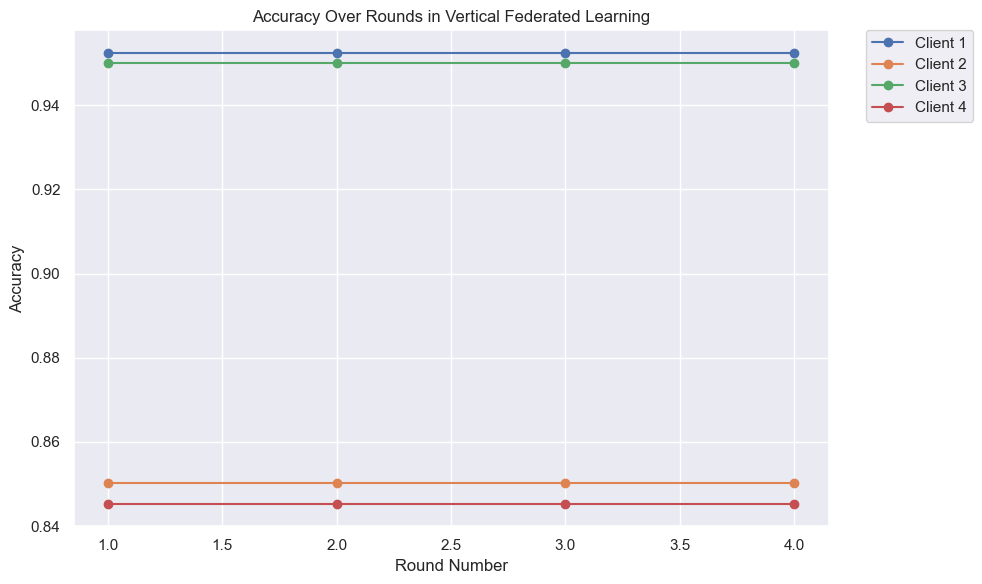

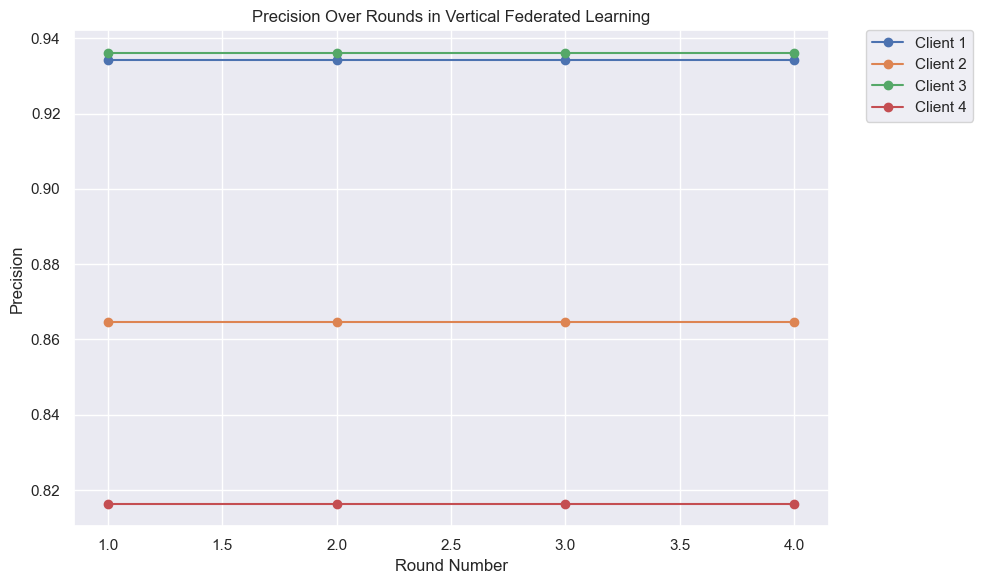

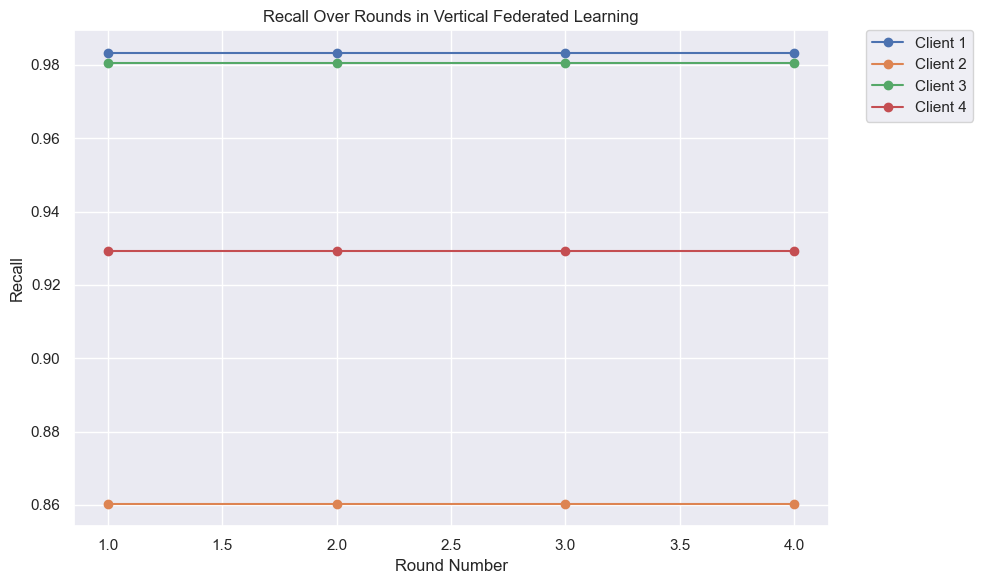

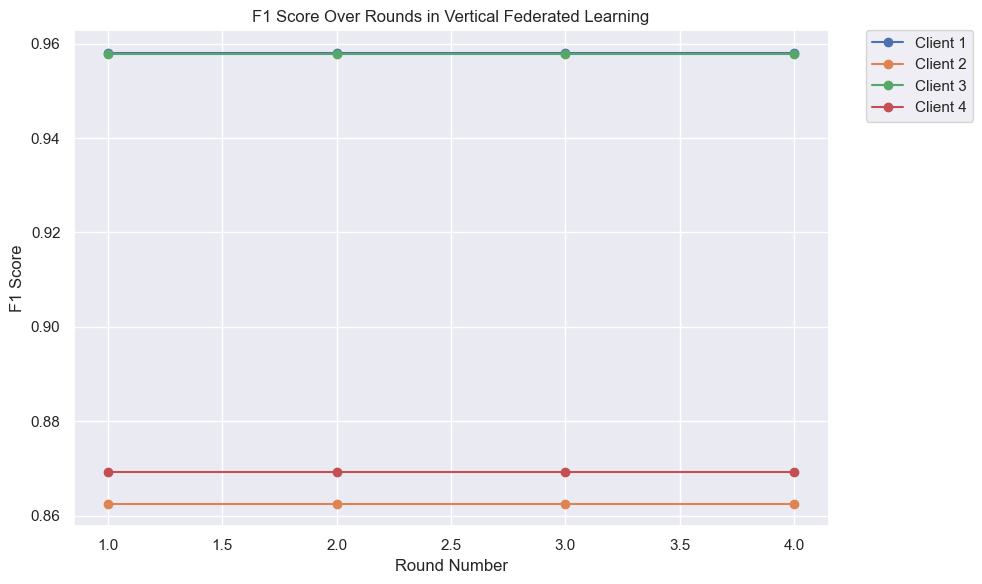


Results and plots saved to VFL_DT_With_DP/results.docx


In [2]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import time
from docx import Document
from docx.shared import Inches
import matplotlib.pyplot as plt
import seaborn as sns
import io
import os
from collections import defaultdict

class FederatedDecisionTree:
    def __init__(self, max_depth=3, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.tree = None
        self.feature_importances_ = None
    
    def fit(self, X, y):
        self.tree = self._build_tree(X, y, depth=0)
        self._compute_feature_importances()
        return self
    
    def _build_tree(self, X, y, depth):
        n_samples, n_features = X.shape
        n_classes = len(np.unique(y))
        
        # Stopping criteria
        if (depth >= self.max_depth or 
            n_samples < self.min_samples_split or 
            n_classes == 1):
            leaf_value = np.argmax(np.bincount(y))
            return {'leaf': True, 'value': leaf_value, 'samples': n_samples}
        
        # Find best split
        best_split = self._find_best_split(X, y)
        if best_split['gain'] <= 0:
            leaf_value = np.argmax(np.bincount(y))
            return {'leaf': True, 'value': leaf_value, 'samples': n_samples}
        
        # Split the data
        left_idx = X[:, best_split['feature']] <= best_split['threshold']
        right_idx = X[:, best_split['feature']] > best_split['threshold']
        
        # Build subtrees
        left_subtree = self._build_tree(X[left_idx], y[left_idx], depth + 1)
        right_subtree = self._build_tree(X[right_idx], y[right_idx], depth + 1)
        
        return {
            'leaf': False,
            'feature': best_split['feature'],
            'threshold': best_split['threshold'],
            'gain': best_split['gain'],
            'left': left_subtree,
            'right': right_subtree,
            'samples': n_samples
        }
    
    def _find_best_split(self, X, y):
        n_samples, n_features = X.shape
        best_split = {'gain': -np.inf}
        
        for feature_idx in range(n_features):
            thresholds = np.unique(X[:, feature_idx])
            for threshold in thresholds:
                gain = self._information_gain(X, y, feature_idx, threshold)
                if gain > best_split['gain']:
                    best_split = {
                        'feature': feature_idx,
                        'threshold': threshold,
                        'gain': gain
                    }
        return best_split
    
    def _information_gain(self, X, y, feature_idx, threshold):
        # Parent entropy
        parent_entropy = self._entropy(y)
        
        # Split data
        left_idx = X[:, feature_idx] <= threshold
        right_idx = X[:, feature_idx] > threshold
        
        if len(y[left_idx]) == 0 or len(y[right_idx]) == 0:
            return 0
        
        # Weighted child entropy
        n = len(y)
        n_left, n_right = len(y[left_idx]), len(y[right_idx])
        child_entropy = (n_left/n) * self._entropy(y[left_idx]) + (n_right/n) * self._entropy(y[right_idx])
        
        # Information gain
        return parent_entropy - child_entropy
    
    def _entropy(self, y):
        hist = np.bincount(y)
        ps = hist / np.sum(hist)
        return -np.sum([p * np.log2(p) for p in ps if p > 0])
    
    def _compute_feature_importances(self):
        importances = np.zeros(self.tree['samples'])
        self._compute_feature_importance_recursive(self.tree, importances)
        self.feature_importances_ = importances / np.sum(importances)
    
    def _compute_feature_importance_recursive(self, node, importances):
        if node['leaf']:
            return
        
        importances[node['feature']] += node['gain'] * node['samples']
        self._compute_feature_importance_recursive(node['left'], importances)
        self._compute_feature_importance_recursive(node['right'], importances)
    
    def predict(self, X):
        if X.shape[0] == 0:
            return np.array([])
        return np.array([self._predict_single(x, self.tree) for x in X])
    
    def _predict_single(self, x, node):
        if node['leaf']:
            return node['value']
        # Ensure feature_idx is a valid integer within bounds
        # The padding should prevent out-of-bounds issues if the tree structure is valid
        feature_idx = int(round(node['feature'])) # node['feature'] should ideally be an int index
        if feature_idx < 0 or feature_idx >= len(x):
            # Fallback: if a noisy tree somehow gets an invalid feature index,
            # predict the majority class of the node's data (or a default).
            # This is a safeguard, the root cause should be fixed by not noising feature indices.
            #  print(f"Warning: Invalid feature index {feature_idx} encountered during prediction.")
             # Find the majority class of the samples that reached this node in the original training
             # This is complex without the original data subsets. A simpler fallback is 0 or the tree's overall majority.
             # For now, return the value of the left child if it's a leaf, otherwise a default.
             # A better approach would be to reconstruct the majority class at this node during tree building/aggregation.
             # As a temporary fix, we'll try the left branch if index is bad, or default to 0
             if not node['left']['leaf']:
                  # If left is not a leaf, something is wrong with the tree structure
                  # Fallback to a default value
                  return 0
             return node['left']['value'] # return left leaf value as a guess


        if x[feature_idx] <= node['threshold']:
            return self._predict_single(x, node['left'])
        else:
            return self._predict_single(x, node['right'])

def decision_tree_local_update(dataset, tree_params, max_depth=3, min_samples_split=2):
    model = FederatedDecisionTree(max_depth=max_depth, min_samples_split=min_samples_split)
    model.fit(dataset["features"], dataset["labels"])
    return model.tree

def clip_tree(tree, threshold):
    """Clip the gain values in the tree to ensure differential privacy"""
    if tree['leaf']:
        return tree
    
    clipped_tree = {
        'leaf': False,
        'feature': tree['feature'],
        'threshold': tree['threshold'],
        'gain': min(tree['gain'], threshold),
        'samples': tree['samples'],
        'left': clip_tree(tree['left'], threshold),
        'right': clip_tree(tree['right'], threshold)
    }
    return clipped_tree

def evaluate_model(dataset, tree):
    X = dataset["features"]
    y = dataset["labels"]
    model = FederatedDecisionTree()
    model.tree = tree
    y_pred = model.predict(X)
    acc = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred, zero_division=0)
    rec = recall_score(y, y_pred, zero_division=0)
    f1 = f1_score(y, y_pred, zero_division=0)
    return acc, prec, rec, f1

def extract_tree_parameters(tree):
    """Extract all important parameters from a tree in a flat structure"""
    params = {}
    if tree['leaf']:
        params['leaf_value'] = tree['value']
        params['samples'] = tree['samples']
    else:
        params['feature'] = tree['feature']
        params['threshold'] = tree['threshold']
        params['gain'] = tree['gain']
        params['samples'] = tree['samples']
        
        # Recursively extract left and right subtree parameters
        left_params = extract_tree_parameters(tree['left'])
        right_params = extract_tree_parameters(tree['right'])
        
        # Prefix the keys to avoid collisions
        for k, v in left_params.items():
            params[f'left_{k}'] = v
        for k, v in right_params.items():
            params[f'right_{k}'] = v
    
    return params

def flatten_tree_parameters(tree_params):
    """Convert nested tree parameters to a flat dictionary with proper naming"""
    flat_params = {}
    for k, v in tree_params.items():
        if isinstance(v, dict):
            for sub_k, sub_v in flatten_tree_parameters(v).items():
                flat_params[f"{k}_{sub_k}"] = sub_v
        else:
            flat_params[k] = v
    return flat_params

def compare_tree_parameters(before_tree, after_tree):
    """Compare parameters between two trees and return differences"""
    before_params = extract_tree_parameters(before_tree)
    after_params = extract_tree_parameters(after_tree)
    
    differences = {}
    all_keys = set(before_params.keys()).union(set(after_params.keys()))
    
    for key in all_keys:
        before_val = before_params.get(key, 0)
        after_val = after_params.get(key, 0)
        
        if isinstance(before_val, (int, float)) and isinstance(after_val, (int, float)):
            if before_val != after_val:
                differences[key] = (before_val, after_val)
    
    return differences

def federated_learning_Using_DT_DP(
    datasets, initial_trees, max_depth, min_samples_split, 
    sigma_local, clipping_threshold, num_rounds
):
    trees = [tree.copy() for tree in initial_trees]
    results = []
    timing_results = []
    best_global_acc = 0.0
    patience = 3
    no_improvement = 0
    
    # Initialize metric histories
    accuracy_history = {f"Client {i+1}": [] for i in range(len(datasets))}
    precision_history = {f"Client {i+1}": [] for i in range(len(datasets))}
    recall_history = {f"Client {i+1}": [] for i in range(len(datasets))}
    f1_history = {f"Client {i+1}": [] for i in range(len(datasets))}
    confusion_matrices = {f"Client {i+1}": [] for i in range(len(datasets))}
    
    global_accuracy = []
    global_precision = []
    global_recall = []
    global_f1 = []

    for round_num in range(1, num_rounds + 1):
        round_start_time = time.time()
        local_tree_updates = []
        local_clipped_trees = []
        target_accuracies = []
        noise_added_during_sharing = []  # Track noise added during sharing
        parameter_differences = []  # Track differences between before and after DP

        # Client updates
        client_update_times = {i: 0 for i in range(len(datasets))}
        for i, dataset in enumerate(datasets):
            client_start_time = time.time()
            
            if round_num == 1:
                # Initial training on dataset
                tree_update = decision_tree_local_update(
                    dataset, trees[i], max_depth, min_samples_split
                )
            else:
                # Subsequent rounds: Use previous adjusted tree directly
                tree_update = trees[i].copy()

            # Clip tree gains
            clipped_tree = clip_tree(tree_update, clipping_threshold)

            # Evaluate before DP and store target accuracy
            acc, prec, rec, f1 = evaluate_model(dataset, clipped_tree)
            target_accuracies.append(acc)
            local_clipped_trees.append(clipped_tree)
            
            # Store metrics for visualization
            accuracy_history[f"Client {i+1}"].append(acc)
            precision_history[f"Client {i+1}"].append(prec)
            recall_history[f"Client {i+1}"].append(rec)
            f1_history[f"Client {i+1}"].append(f1)
            
            # Store confusion matrix
            X = dataset["features"]
            y = dataset["labels"]
            model = FederatedDecisionTree()
            model.tree = clipped_tree
            y_pred = model.predict(X)
            cm = confusion_matrix(y, y_pred)
            confusion_matrices[f"Client {i+1}"].append(cm)

            # Add local DP noise to the tree gains
            noisy_tree = add_noise_to_tree(clipped_tree, sigma_local)
            noise_added_during_sharing.append(get_tree_noise(clipped_tree, noisy_tree))
            
            # Compare parameters before and after DP
            param_diff = compare_tree_parameters(clipped_tree, noisy_tree)
            parameter_differences.append({
                'client': i+1,
                'round': round_num,
                'differences': param_diff
            })

            local_tree_updates.append(noisy_tree)

            # Log before DP with parameter details
            before_dp_params = extract_tree_parameters(clipped_tree)
            results.append({
                "Round": round_num, 
                "Client": i+1, 
                "Stage": "Before DP",
                "Accuracy": round(acc, 4), 
                "Precision": round(prec, 4), 
                "Recall": round(rec, 4), 
                "F1 Score": round(f1, 4),
                "Parameters": before_dp_params
            })
            
            # Log after DP with parameter details
            acc_dp, prec_dp, rec_dp, f1_dp = evaluate_model(dataset, noisy_tree)
            after_dp_params = extract_tree_parameters(noisy_tree)
            results.append({
                "Round": round_num, 
                "Client": i+1, 
                "Stage": "After DP",
                "Accuracy": round(acc_dp, 4), 
                "Precision": round(prec_dp, 4), 
                "Recall": round(rec_dp, 4), 
                "F1 Score": round(f1_dp, 4),
                "Parameters": after_dp_params,
                "Parameter Differences": param_diff
            })
            
            client_end_time = time.time()
            client_update_times[i] = (client_end_time - client_start_time)

        # Aggregate noisy trees (select best splits)
        aggregation_start_time = time.time()
        aggregated_tree = aggregate_trees(local_tree_updates)
        aggregation_time = (time.time() - aggregation_start_time)

        # Log noisy aggregated model
        combined_data = {
            "features": np.vstack([d["features"] for d in datasets]),
            "labels": np.hstack([d["labels"] for d in datasets])
        }
        acc_noisy, prec_noisy, rec_noisy, f1_noisy = evaluate_model(combined_data, aggregated_tree)
        results.append({
            "Round": round_num, 
            "Client": "Global Server", 
            "Stage": "Aggregated (Noisy)",
            "Accuracy": round(acc_noisy, 4), 
            "Precision": round(prec_noisy, 4),
            "Recall": round(rec_noisy, 4), 
            "F1 Score": round(f1_noisy, 4),
            "Parameters": extract_tree_parameters(aggregated_tree)
        })

        # Client adjustment phase
        adjustment_times = {i: 0 for i in range(len(datasets))}
        denoising_times = {i: 0 for i in range(len(datasets))}
        for i in range(len(datasets)):
            adjustment_start_time = time.time()
            dataset = datasets[i]

            # Get THIS ROUND'S before-DP accuracy as the target
            target_acc = target_accuracies[i]  # Pre-DP accuracy from the current round

            # Get original clipped tree (before DP noise) for this client
            clipped_tree = local_clipped_trees[i]  # Pre-DP tree

            # Denoise the aggregated global tree
            denoise_start_time = time.time()
            noise_tree = noise_added_during_sharing[i]
            denoised_tree = subtract_noise_from_tree(aggregated_tree, noise_tree)
            denoising_times[i] = (time.time() - denoise_start_time)

            # Compute delta: Difference between client's original clipped tree and denoised global
            X = dataset["features"]
            y = dataset["labels"]
            
            # Create models for comparison
            original_model = FederatedDecisionTree()
            original_model.tree = clipped_tree
            
            global_model = FederatedDecisionTree()
            global_model.tree = denoised_tree
            
            # Get predictions
            y_pred_original = original_model.predict(X)
            y_pred_global = global_model.predict(X)
            
            # Find alpha that best matches original accuracy
            best_alpha = 0.0
            best_acc = 0.0
            
            for alpha in np.linspace(0, 1, 11):  # Test 0%, 10%, ..., 100% interpolation
                # For trees, we'll create an interpolated prediction
                y_pred_test = np.where(
                    np.random.rand(len(y_pred_original)) < alpha,
                    y_pred_original,
                    y_pred_global
                )
                acc = accuracy_score(y, y_pred_test)
                
                if acc >= target_acc:
                    best_alpha = alpha
                    best_acc = acc
                    break
                if acc > best_acc:
                    best_alpha = alpha
                    best_acc = acc
            
            # Update client tree - for trees we'll probabilistically choose between
            # the original and global tree based on alpha
            if np.random.rand() < best_alpha:
                new_tree = clipped_tree
            else:
                new_tree = denoised_tree

            # Log adjusted model
            acc_adj, prec_adj, rec_adj, f1_adj = evaluate_model(dataset, new_tree)
            results.append({
                "Round": round_num, 
                "Client": i+1, 
                "Stage": "Adjusted",
                "Accuracy": round(acc_adj, 4), 
                "Precision": round(prec_adj, 4), 
                "Recall": round(rec_adj, 4), 
                "F1 Score": round(f1_adj, 4),
                "Parameters": extract_tree_parameters(new_tree)
            })

            # Update client trees
            trees[i] = new_tree
            
            adjustment_end_time = time.time()
            adjustment_times[i] = (adjustment_end_time - adjustment_start_time)

        # Evaluate global model (ensemble of client trees)
        global_eval_start_time = time.time()
        global_acc_round, global_prec_round, global_rec_round, global_f1_round = evaluate_ensemble(datasets, trees)
        global_eval_time = (time.time() - global_eval_start_time)
        
        results.append({
            "Round": round_num, 
            "Client": "Global Model", 
            "Stage": "Post Adjustment",
            "Accuracy": round(global_acc_round, 4), 
            "Precision": round(global_prec_round, 4), 
            "Recall": round(global_rec_round, 4), 
            "F1 Score": round(global_f1_round, 4),
            "Parameters": [extract_tree_parameters(t) for t in trees]
        })
        
        # Store global metrics
        global_accuracy.append(global_acc_round)
        global_precision.append(global_prec_round)
        global_recall.append(global_rec_round)
        global_f1.append(global_f1_round)

        # Record timing for this round with per-client details
        round_end_time = time.time()
        round_time = (round_end_time - round_start_time)
        
        # Create timing entry with per-client details
        timing_entry = {
            "Round": round_num,
            "Round Time (s)": round(round_time, 4),
            "Aggregation Time (s)": round(aggregation_time, 4),
            "Global Eval Time (s)": round(global_eval_time, 4)
        }
        
        # Add per-client timing details
        for i in range(len(datasets)):
            timing_entry[f"Client {i+1} Update Time (s)"] = round(client_update_times[i], 4)
            timing_entry[f"Client {i+1} Denoising Time (s)"] = round(denoising_times[i], 4)
            timing_entry[f"Client {i+1} Adjustment Time (s)"] = round(adjustment_times[i], 4)
        
        timing_results.append(timing_entry)

        # Early stopping
        if global_acc_round > best_global_acc + 0.0001:
            best_global_acc = global_acc_round
            no_improvement = 0
        else:
            no_improvement += 1
        if no_improvement >= patience:
            print(f"Early stopping at round {round_num}")
            break

    # Final evaluation
    final_acc, final_prec, final_rec, final_f1 = evaluate_ensemble(datasets, trees)
    print(f"\nFinal Global Model Accuracy: {final_acc:.4f}")
    print(f"Final Global Model Precision: {final_prec:.4f}")
    print(f"Final Global Model Recall: {final_rec:.4f}")
    print(f"Final Global Model F1 Score: {final_f1:.4f}")
    
    # Convert results to DataFrame
    results_df = pd.DataFrame(results)
    
    # Format parameters for display
    def format_params(params):
        if isinstance(params, dict):
            return ", ".join([f"{k}: {round(v, 4)}" for k, v in params.items() if isinstance(v, (int, float))])
        elif isinstance(params, list):
            return "\n".join([format_params(p) for p in params])
        return str(params)
    
    results_df['Parameters'] = results_df['Parameters'].apply(format_params)
    
    # Format parameter differences
    def format_param_diffs(diffs):
        if not isinstance(diffs, dict):
            return ""
        return "\n".join([f"{k}: {round(v[0],4)}→{round(v[1],4)}" for k, v in diffs.items()])
    
    if 'Parameter Differences' in results_df.columns:
        results_df['Parameter Differences'] = results_df['Parameter Differences'].apply(format_param_diffs)
    
    timing_df = pd.DataFrame(timing_results)
    
    print("\nPerformance Results:")
    print(results_df.to_markdown(index=False))
    
    print("\nTiming Results:")
    print(timing_df.to_markdown(index=False))
    
    # Print parameter differences
    print("\nParameter Differences Between Before DP and After DP:")
    for diff in parameter_differences:
        print(f"\nClient {diff['client']}, Round {diff['round']}:")
        for param, (before, after) in diff['differences'].items():
            print(f"{param}: {before:.4f} -> {after:.4f} (Δ {after-before:.4f})")
    
    # Ensure all metric arrays have the same length
    actual_rounds = len(global_accuracy)
    for client in accuracy_history:
        accuracy_history[client] = accuracy_history[client][:actual_rounds]
        precision_history[client] = precision_history[client][:actual_rounds]
        recall_history[client] = recall_history[client][:actual_rounds]
        f1_history[client] = f1_history[client][:actual_rounds]
        confusion_matrices[client] = confusion_matrices[client][:actual_rounds]
    
    # Plot metrics
    plot_metrics(accuracy_history, precision_history, recall_history, f1_history, 
                len(datasets), actual_rounds)
    
    # Save results and plots
    save_results_and_plots(results_df, timing_df, accuracy_history, precision_history, recall_history, 
                         f1_history, confusion_matrices, len(datasets), actual_rounds, parameter_differences)
    
    return results_df, timing_df, trees, parameter_differences

# Helper functions for tree operations
def add_noise_to_tree(tree, sigma):
    """Add Gaussian noise to all gain values in the tree"""
    if tree['leaf']:
        return tree
    
    noisy_tree = {
        'leaf': False,
        'feature': tree['feature'] + np.random.normal(0, sigma),
        'threshold': tree['threshold'] + np.random.normal(0, sigma),
        'gain': tree['gain'] + np.random.normal(0, sigma),
        'samples': tree['samples'],
        'left': add_noise_to_tree(tree['left'], sigma),
        'right': add_noise_to_tree(tree['right'], sigma)
    }
    return noisy_tree

def get_tree_noise(original_tree, noisy_tree):
    """Extract the noise added to a tree"""
    if original_tree['leaf'] and noisy_tree['leaf']:
        return None
    
    noise = {
        'gain': noisy_tree['gain'] - original_tree['gain']
    }
    
    if not original_tree['leaf'] and not noisy_tree['leaf']:
        noise['left'] = get_tree_noise(original_tree['left'], noisy_tree['left'])
        noise['right'] = get_tree_noise(original_tree['right'], noisy_tree['right'])
    
    return noise

def subtract_noise_from_tree(noisy_tree, noise_tree):
    """Remove noise from a tree"""
    if noisy_tree['leaf']:
        return noisy_tree
    
    denoised_tree = {
        'leaf': False,
        'feature': noisy_tree['feature'],
        'threshold': noisy_tree['threshold'],
        'gain': noisy_tree['gain'] - noise_tree['gain'],
        'samples': noisy_tree['samples'],
        'left': subtract_noise_from_tree(noisy_tree['left'], noise_tree['left']),
        'right': subtract_noise_from_tree(noisy_tree['right'], noise_tree['right'])
    }
    return denoised_tree

def aggregate_trees(trees):
    """Aggregate trees by selecting splits with highest (noisy) gain"""
    if all(tree['leaf'] for tree in trees):
        # If all are leaves, return one of them
        return trees[0]
    
    # Find the tree with the highest root gain
    best_tree = max(trees, key=lambda t: t['gain'] if not t['leaf'] else -np.inf)
    
    if best_tree['leaf']:
        return best_tree
    
    # Recursively aggregate subtrees
    aggregated_tree = {
        'leaf': False,
        'feature': best_tree['feature'],
        'threshold': best_tree['threshold'],
        'gain': best_tree['gain'],
        'samples': sum(tree['samples'] for tree in trees),
        'left': aggregate_trees([tree['left'] for tree in trees]),
        'right': aggregate_trees([tree['right'] for tree in trees])
    }
    return aggregated_tree

def evaluate_ensemble(datasets, trees):
    """Evaluate an ensemble of trees (majority voting)"""
    combined_data = {
        "features": np.vstack([d["features"] for d in datasets]),
        "labels": np.hstack([d["labels"] for d in datasets])
    }
    X = combined_data["features"]
    y = combined_data["labels"]
    
    # Create predictions from all trees
    predictions = []
    for tree in trees:
        model = FederatedDecisionTree()
        model.tree = tree
        predictions.append(model.predict(X))
    
    # Majority voting
    y_pred = np.round(np.mean(predictions, axis=0))
    
    acc = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred, zero_division=0)
    rec = recall_score(y, y_pred, zero_division=0)
    f1 = f1_score(y, y_pred, zero_division=0)
    
    return acc, prec, rec, f1

def plot_metrics(accuracy, precision, recall, f1_score, 
                num_clients, num_rounds):
    """Plot the metrics over rounds for each client and global model."""
    sns.set(style="darkgrid")
    rounds = list(range(1, num_rounds + 1))
    
    def plot_metric(metric_data, title, ylabel):
        plt.figure(figsize=(10, 6))
        for client, values in metric_data.items():
            plt.plot(rounds, values[:num_rounds], marker='o', label=client)
        
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
        plt.xlabel("Round Number")
        plt.ylabel(ylabel)
        plt.title(title)
        plt.tight_layout()
        plt.show()
        
    # Plot each metric
    plot_metric(accuracy, "Accuracy Over Rounds in Vertical Federated Learning", "Accuracy")
    plot_metric(precision, "Precision Over Rounds in Vertical Federated Learning", "Precision")
    plot_metric(recall, "Recall Over Rounds in Vertical Federated Learning", "Recall")
    plot_metric(f1_score, "F1 Score Over Rounds in Vertical Federated Learning", "F1 Score")

def save_results_and_plots(results_df, timing_df, accuracy, precision, recall, f1_score, 
                         confusion_matrices, num_clients, num_rounds, parameter_differences):
    """Save all results and plots to a Word document."""
    if not os.path.exists("VFL_DT_With_DP"):
        os.makedirs("VFL_DT_With_DP")
    
    doc = Document()
    doc.add_heading('Federated Decision Tree Learning Results (With DP)', 0)
    
    # Add summary statistics
    doc.add_heading('Summary Statistics', level=1)
    final_metrics = results_df[results_df['Stage'] == 'Post Adjustment'].iloc[-1]
    doc.add_paragraph(f"Final Global Model Performance:")
    doc.add_paragraph(f"Accuracy: {final_metrics['Accuracy']:.4f}")
    doc.add_paragraph(f"Precision: {final_metrics['Precision']:.4f}")
    doc.add_paragraph(f"Recall: {final_metrics['Recall']:.4f}")
    doc.add_paragraph(f"F1 Score: {final_metrics['F1 Score']:.4f}")
    
    # Add timing results
    doc.add_heading('Timing Results (Seconds)', level=1)
    timing_table = doc.add_table(timing_df.shape[0]+1, timing_df.shape[1])
    timing_table.style = 'Table Grid'
    
    # Add headers
    hdr_cells = timing_table.rows[0].cells
    for i, col in enumerate(timing_df.columns):
        hdr_cells[i].text = col
    
    # Add data rows
    for i, row in timing_df.iterrows():
        row_cells = timing_table.add_row().cells
        for j, value in enumerate(row):
            row_cells[j].text = f"{value:.4f}" if isinstance(value, (float, np.floating)) else str(value)
    
    # Add detailed results table
    doc.add_heading('Detailed Results', level=1)
    table = doc.add_table(rows=1, cols=len(results_df.columns))
    table.style = 'Table Grid'
    
    # Add headers
    hdr_cells = table.rows[0].cells
    for i, col in enumerate(results_df.columns):
        hdr_cells[i].text = col
    
    # Add data rows
    for _, row in results_df.iterrows():
        row_cells = table.add_row().cells
        for i, value in enumerate(row):
            row_cells[i].text = str(value)
    
    # Add parameter differences
    doc.add_heading('Parameter Differences (Before DP vs After DP)', level=1)
    for diff in parameter_differences:
        doc.add_paragraph(f"Client {diff['client']}, Round {diff['round']}:")
        for param, (before, after) in diff['differences'].items():
            doc.add_paragraph(f"{param}: {before:.4f} → {after:.4f} (Δ {after-before:+.4f})")
        doc.add_paragraph()
    
    # Add metric plots
    doc.add_heading('Performance Metrics Over Rounds', level=1)
    rounds = list(range(1, num_rounds + 1))
    
    def add_metric_plot(doc, metric_data, title):
        plt.figure(figsize=(10, 6))
        for client, values in metric_data.items():
            plt.plot(rounds, values[:num_rounds], marker='o', label=client)
        
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
        plt.xlabel("Round Number")
        plt.ylabel(title)
        plt.title(f"{title} Over Rounds")
        plt.tight_layout()
        
        buf = io.BytesIO()
        plt.savefig(buf, format='png', dpi=600, bbox_inches='tight')
        buf.seek(0)
        doc.add_picture(buf, width=Inches(6))
        plt.close()
    
    add_metric_plot(doc, accuracy, "Accuracy")
    add_metric_plot(doc, precision, "Precision")
    add_metric_plot(doc, recall, "Recall")
    add_metric_plot(doc, f1_score, "F1 Score")
    
    # Add timing plots
    doc.add_heading('Timing Analysis', level=1)
    
    plt.figure(figsize=(10, 6))
    plt.plot(timing_df['Round'], timing_df['Round Time (s)'], marker='o')
    plt.xlabel("Round Number")
    plt.ylabel("Time (s)")
    plt.title("Total Round Time")
    plt.grid(True)
    plt.tight_layout()
    
    buf = io.BytesIO()
    plt.savefig(buf, format='png', dpi=600, bbox_inches='tight')
    buf.seek(0)
    doc.add_picture(buf, width=Inches(6))
    plt.close()
    
    # Plot for client-specific times
    plt.figure(figsize=(12, 7))
    client_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    for i in range(1, num_clients + 1):
        plt.plot(timing_df['Round'], timing_df[f'Client {i} Update Time (s)'], 
                marker='o', label=f'Client {i} Update', color=client_colors[i-1])
        plt.plot(timing_df['Round'], timing_df[f'Client {i} Adjustment Time (s)'], 
                marker='^', label=f'Client {i} Adjustment', color=client_colors[i-1], linestyle=':')
    
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    plt.xlabel("Round Number")
    plt.ylabel("Time (s)")
    plt.title("Per-Client Component Times")
    plt.grid(True)
    plt.tight_layout()
    
    buf = io.BytesIO()
    plt.savefig(buf, format='png', dpi=600, bbox_inches='tight')
    buf.seek(0)
    doc.add_picture(buf, width=Inches(6))
    plt.close()
    
    # Add confusion matrices
    doc.add_heading('Final Confusion Matrices', level=1)
    plt.figure(figsize=(15, 10))
    for i in range(1, num_clients + 1):
        plt.subplot(2, 2, i)
        cm = confusion_matrices[f"Client {i}"][-1]
        sns.heatmap(cm, annot=True, fmt='d')
        plt.title(f'Client {i} Confusion Matrix')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
    plt.tight_layout()
    
    buf = io.BytesIO()
    plt.savefig(buf, format='png', dpi=600, bbox_inches='tight')
    buf.seek(0)
    doc.add_picture(buf, width=Inches(6))
    plt.close()
    
    doc.save("VFL_DT_With_DP/results.docx")
    print("\nResults and plots saved to VFL_DT_With_DP/results.docx")


# Example usage (assuming you have client data):
datasets = [client_1_data, client_2_data, client_3_data, client_4_data]

# Padding features to ensure uniform length
def pad_features_to_max_size(datasets):
    max_features = max(d["features"].shape[1] for d in datasets)
    for d in datasets:
        pad_width = max_features - d["features"].shape[1]
        if pad_width > 0:
            d["features"] = np.hstack([d["features"], np.zeros((d["features"].shape[0], pad_width))])
    return datasets, max_features

# Pad datasets and initialize weights
datasets, max_features = pad_features_to_max_size(datasets)
    
# Initialize empty trees
initial_trees = []
for _ in range(len(datasets)):
    initial_trees.append({
        'leaf': True,
        'value': 0,
        'samples': 0
    })
    
# Run Federated Learning with Decision Trees
results_df, timing_df, final_trees, param_diffs = federated_learning_Using_DT_DP(
    datasets=datasets,
    initial_trees=initial_trees,
    max_depth=3,
    min_samples_split=2,
    sigma_local=1.0,
    clipping_threshold=3.0,
    num_rounds=10
)